In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data=pd.read_csv("/content/drive/MyDrive/Data mining and machine learning /weather_data.csv")

In [ ]:
data

,day,temperature,windspeed,event
0,1/1/2017,32.0,6.0,Rain
1,1/4/2017,NaN,7.0,Sunny
2,1/5/2017,28.0,NaN,Snow
3,1/6/2017,NaN,7.0,NaN
4,1/7/2017,32.0,NaN,Rain
5,1/8/2017,31.0,2.0,Sunny
6,1/9/2017,NaN,NaN,NaN
7,1/10/2017,34.0,8.0,Cloudy
8,1/11/2017,40.0,12.0,Sunny


In [ ]:
data.isna().sum()

,0
day,0
temperature,3
windspeed,3
event,2


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          9 non-null      object 
 1   temperature  6 non-null      float64
 2   windspeed    6 non-null      float64
 3   event        7 non-null      object 
dtypes: float64(2), object(2)
memory usage: 416.0+ bytes


In [ ]:
data.describe()

,temperature,windspeed
count,6.000000,6.000000
mean,32.833333,7.000000
std,4.020779,3.224903
min,28.000000,2.000000
25%,31.250000,6.250000
50%,32.000000,7.000000
75%,33.500000,7.750000
max,40.000000,12.000000


In [ ]:
data.dtypes

,0
day,object
temperature,float64
windspeed,float64
event,object


In [ ]:
data.shape

(9, 4)

In [ ]:
data.columns

Index(['day', 'temperature', 'windspeed', 'event'], dtype='object')

In [ ]:
data['day']

,day
0,1/1/2017
1,1/4/2017
2,1/5/2017
3,1/6/2017
4,1/7/2017
5,1/8/2017
6,1/9/2017
7,1/10/2017
8,1/11/2017


In [ ]:
data.event.value_counts()
#data['event'].value_counts()

,count
event,
Sunny,3
Rain,2
Snow,1
Cloudy,1


In [ ]:
data.nunique()

,0
day,9
temperature,5
windspeed,5
event,4


In [ ]:
data.groupby('event').get_group('Rain')

,day,temperature,windspeed,event
0,1/1/2017,32.0,6.0,Rain
4,1/7/2017,32.0,NaN,Rain


In [ ]:
data[data['event']=='Rain']

,day,temperature,windspeed,event
0,1/1/2017,32.0,6.0,Rain
4,1/7/2017,32.0,NaN,Rain


In [ ]:
data.isnull().value_counts()

day    temperature  windspeed  event
False  False        False      False    4
                    True       False    2
       True         False      False    1
                               True     1
                    True       True     1
Name: count, dtype: int64

In [ ]:
data.isnull().sum()

,0
day,0
temperature,3
windspeed,3
event,2


In [ ]:
data['event'].isnull()==True

,event
0,False
1,False
2,False
3,True
4,False
5,False
6,True
7,False
8,False


In [ ]:
newdata=data.fillna(0)

In [ ]:
newdata

,day,temperature,windspeed,event
0,1/1/2017,32.0,6.0,Rain
1,1/4/2017,0.0,7.0,Sunny
2,1/5/2017,28.0,0.0,Snow
3,1/6/2017,0.0,7.0,0
4,1/7/2017,32.0,0.0,Rain
5,1/8/2017,31.0,2.0,Sunny
6,1/9/2017,0.0,0.0,0
7,1/10/2017,34.0,8.0,Cloudy
8,1/11/2017,40.0,12.0,Sunny


In [ ]:
newdata=data.fillna({
    'temperature': 33.0,
    'windspeed': 5.0,
    'event':'Noevent'
})

In [ ]:
newdata

,day,temperature,windspeed,event
0,1/1/2017,32.0,6.0,Rain
1,1/4/2017,33.0,7.0,Sunny
2,1/5/2017,28.0,5.0,Snow
3,1/6/2017,33.0,7.0,Noevent
4,1/7/2017,32.0,5.0,Rain
5,1/8/2017,31.0,2.0,Sunny
6,1/9/2017,33.0,5.0,Noevent
7,1/10/2017,34.0,8.0,Cloudy
8,1/11/2017,40.0,12.0,Sunny


In [ ]:
newdataforwardfill=data.fillna(method='ffill')
newdataforwardfill

<ipython-input-52-91c9a8888fc9>:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  newdataforwardfill=data.fillna(method='ffill')


,day,temperature,windspeed,event
0,1/1/2017,32.0,6.0,Rain
1,1/4/2017,32.0,7.0,Sunny
2,1/5/2017,28.0,7.0,Snow
3,1/6/2017,28.0,7.0,Snow
4,1/7/2017,32.0,7.0,Rain
5,1/8/2017,31.0,2.0,Sunny
6,1/9/2017,31.0,2.0,Sunny
7,1/10/2017,34.0,8.0,Cloudy
8,1/11/2017,40.0,12.0,Sunny


In [ ]:
newdatabackwardfill=data.fillna(method='bfill')
newdatabackwardfill

<ipython-input-51-01d18d50275b>:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  newdatabackwardfill=data.fillna(method='bfill')


,day,temperature,windspeed,event
0,1/1/2017,32.0,6.0,Rain
1,1/4/2017,28.0,7.0,Sunny
2,1/5/2017,28.0,7.0,Snow
3,1/6/2017,32.0,7.0,Rain
4,1/7/2017,32.0,2.0,Rain
5,1/8/2017,31.0,2.0,Sunny
6,1/9/2017,34.0,8.0,Cloudy
7,1/10/2017,34.0,8.0,Cloudy
8,1/11/2017,40.0,12.0,Sunny


In [ ]:
newdata.dropna()

,day,temperature,windspeed,event
0,1/1/2017,32.0,6.0,Rain
1,1/4/2017,32.0,7.0,Sunny
2,1/5/2017,28.0,7.0,Snow
3,1/6/2017,28.0,7.0,Snow
4,1/7/2017,32.0,7.0,Rain
5,1/8/2017,31.0,2.0,Sunny
6,1/9/2017,31.0,2.0,Sunny
7,1/10/2017,34.0,8.0,Cloudy
8,1/11/2017,40.0,12.0,Sunny


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
x=np.arange(0,5)
y=x**2

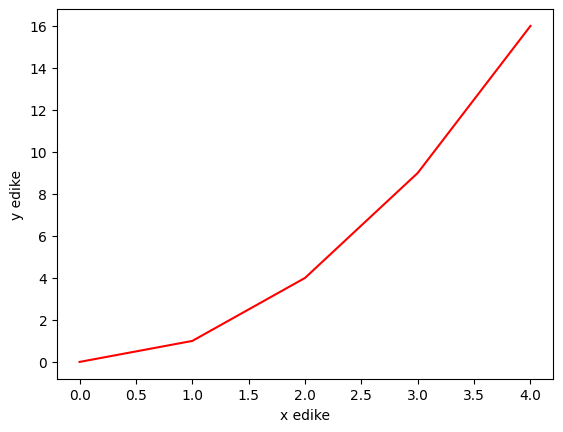

In [ ]:
plt.plot(x,y,'r')#r means red
plt.xlabel('x edike')
plt.ylabel('y edike')
plt.show()

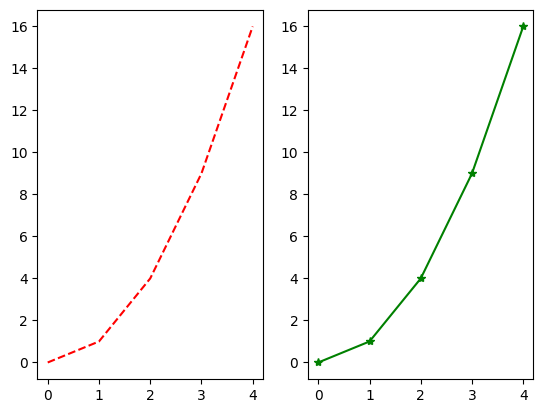

In [ ]:
plt.subplot(1,2,1)
plt.plot(x,y,'r--')
plt.subplot(1,2,2)
plt.plot(x,y,'g-*')
plt.show()